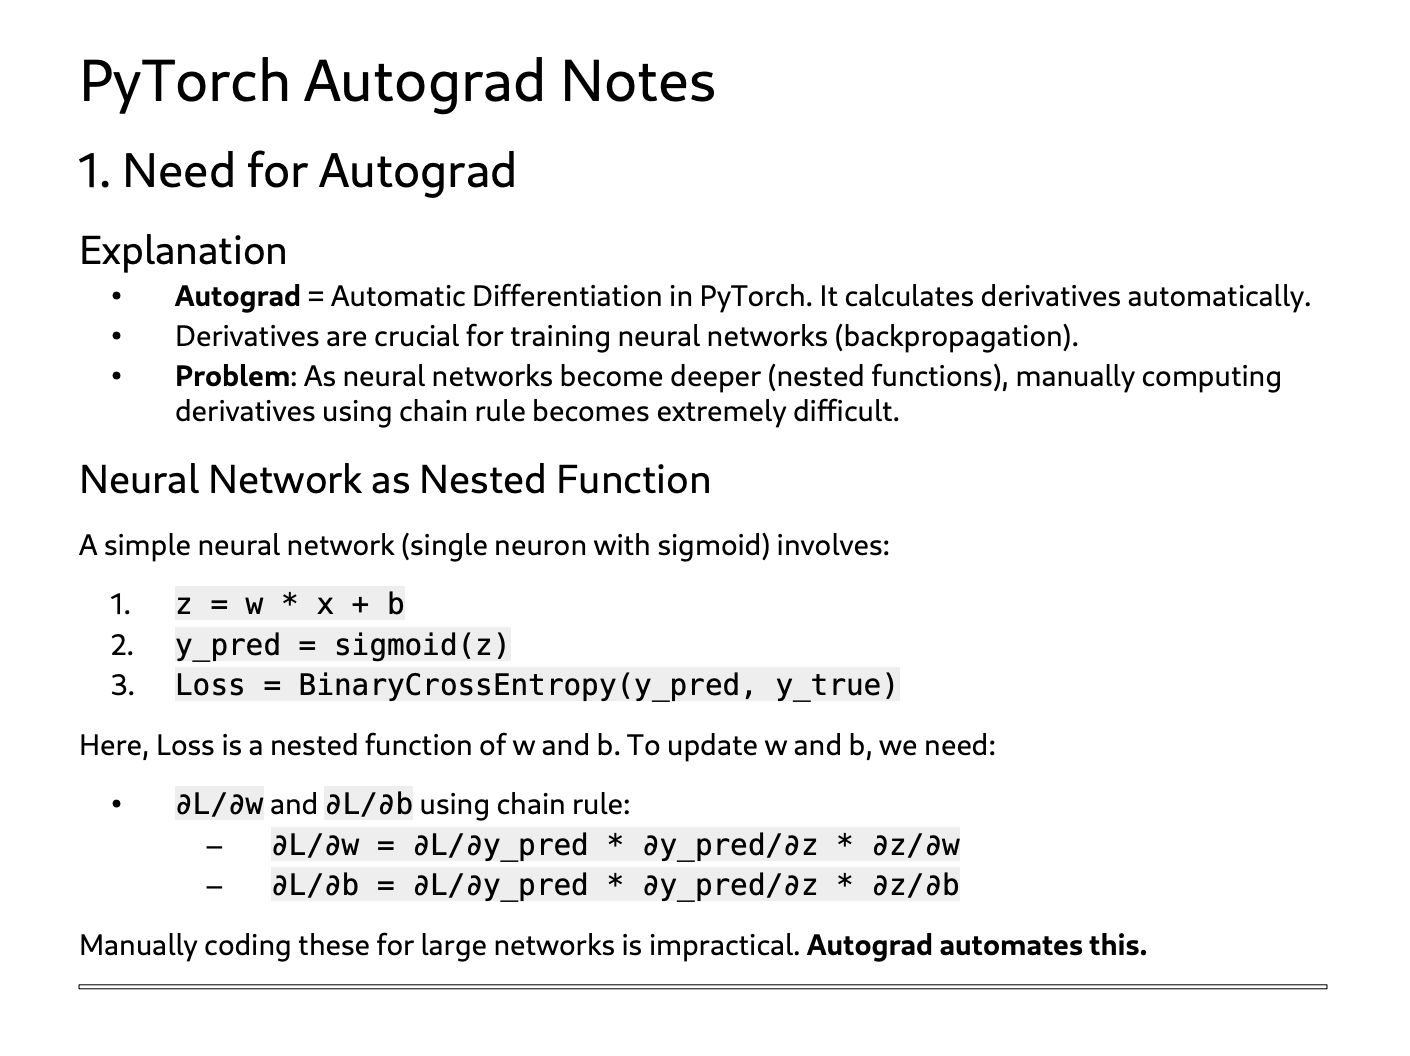

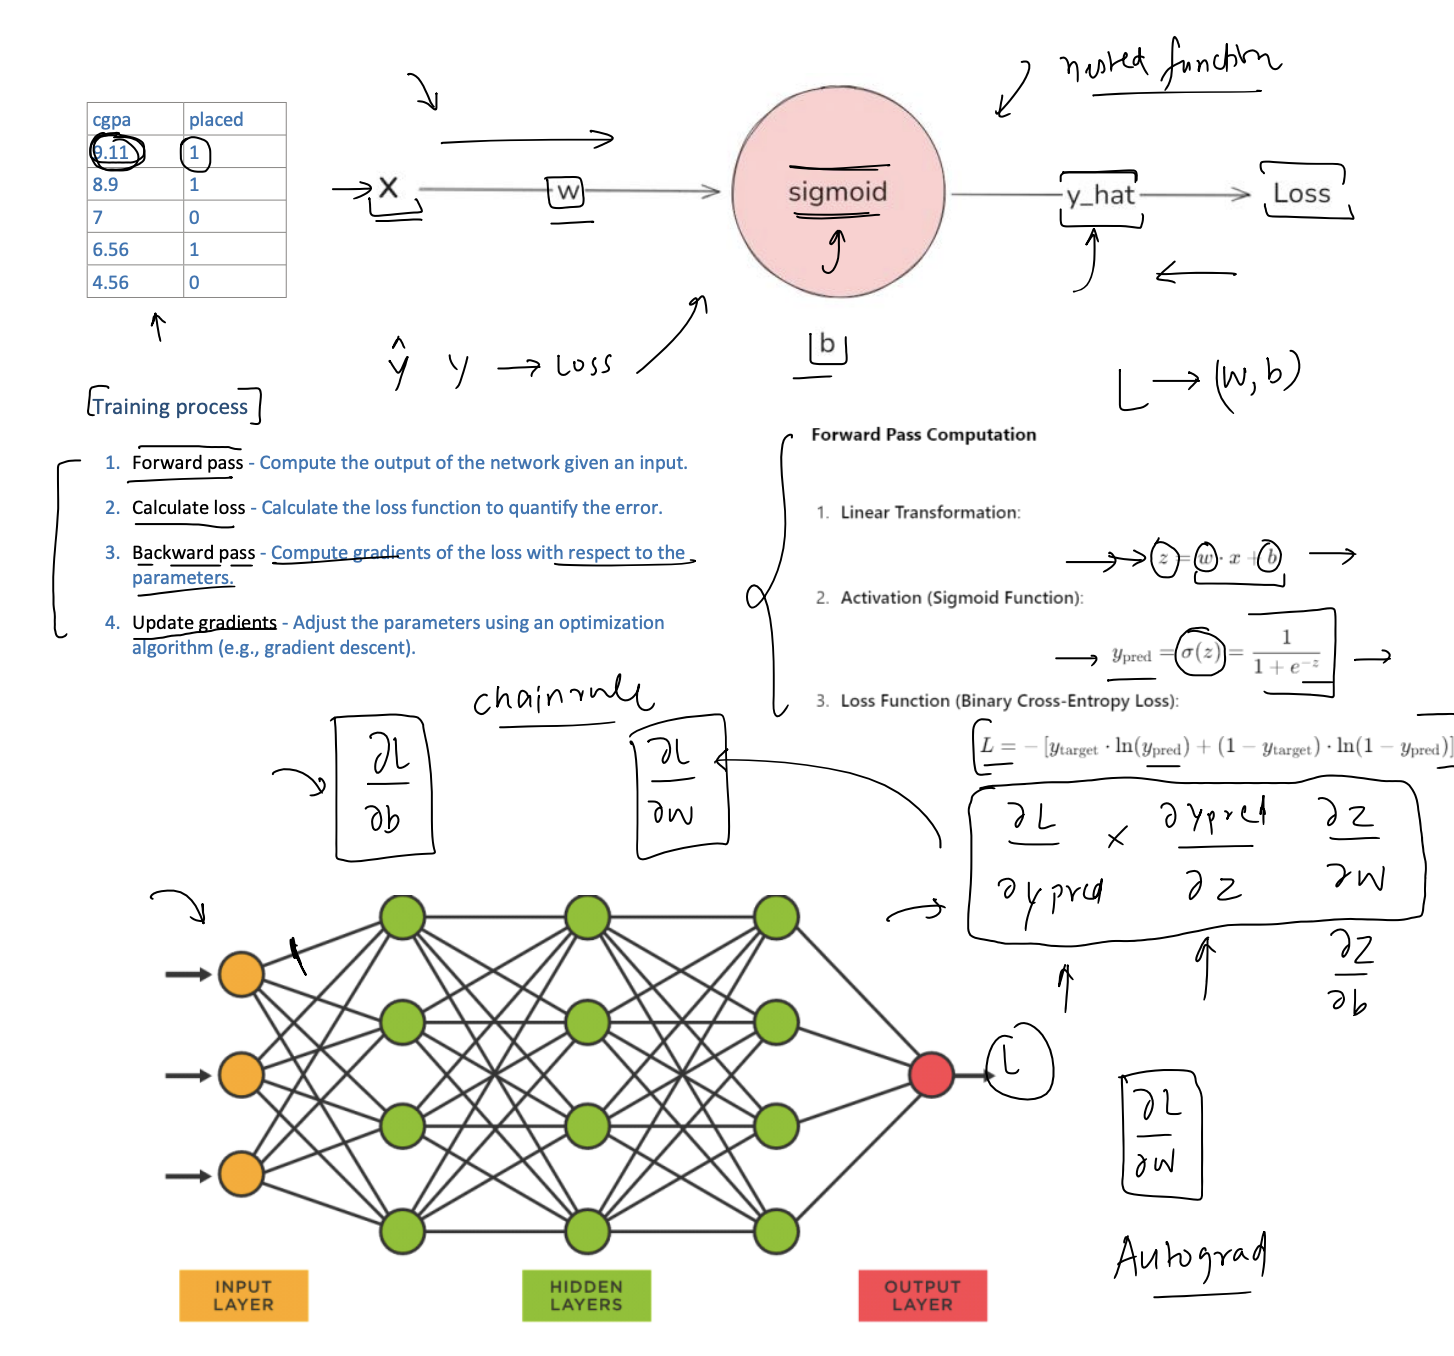

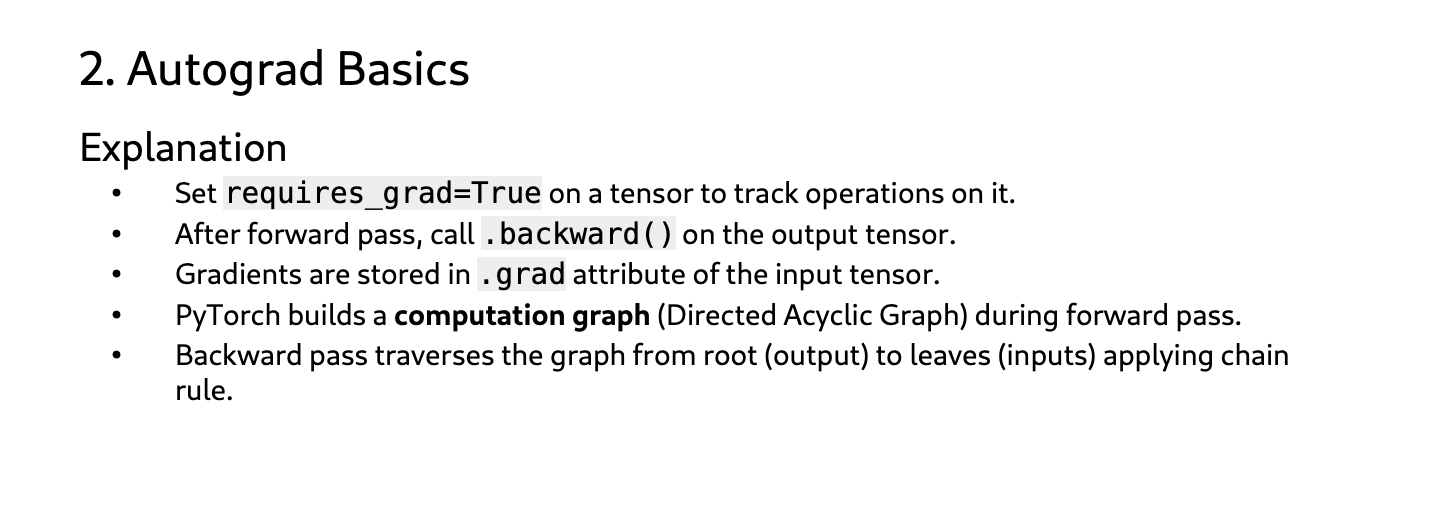

## Manually

### Derivative of x^2 , y=x^2

In [2]:
def dy_dx(x):
  return 2*x

In [4]:
dy_dx(3)

6

## derivative of y=x^2,z=sin(y) find dz/dx

using chain rule
dz/dx=dz/dy * dy/dx

In [20]:
import math
def dz_dx(x):
  return 2*x*math.cos(x**2)

In [21]:
dz_dx(3)

-5.466781571308061

y=x^2
z=sin(y)
u=e^z

du/dx= du/dz * dz/dy * dy/dx

## Using autograd

3. Example 1: y = x²
Explanation
- We want dy/dx at any x.
- Using Autograd: define x with requires_grad=True, compute y, call y.backward(),get x.grad.

In [10]:
import torch

In [ ]:
x=torch.tensor(data=3.0,requires_grad=True) # scalar value , leaf tensor
x

tensor(3., requires_grad=True)

In [ ]:
y=x**2 #operation
y        #powerbackward0 means its remembering the process how y was created so it can later be used for derivatives

tensor(9., grad_fn=<PowBackward0>)

In [ ]:
y.backward() # compute gradients

In [ ]:
x.grad # the actual derivative # dy/dx = 2*x = 6

tensor(6.)

In [ ]:
# For x=4
x = torch.tensor(4.0, requires_grad=True)
y = x ** 2
y.backward()
print(f"dy/dx at x=4: {x.grad}") # 2*4 = 8

### 4. Example 2: Nested Functions (z = sin(x²))
Explanation
- Given: y = x², z = sin(y). Need dz/dx.
- Chain rule: dz/dx = dz/dy * dy/dx = cos(y) * 2x = cos(x²) * 2x.
- Autograd handles it automatically.

In [3]:
import torch
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
z = torch.sin(y)
z.backward()
print(f"dz/dx at x=3: {x.grad}") # cos(9)*6 ≈ -5.46? Actually cos(9)*6 ≈ -5.46? Let's compute: cos(9 rad) ≈ -0.911, times 6 = -5.466

dz/dx at x=3: -5.4667816162109375


In [4]:
# For x=4
x = torch.tensor(4.0, requires_grad=True)
y = x ** 2
z = torch.sin(y)
z.backward()
print(f"dz/dx at x=4: {x.grad}") # cos(16)*8 ≈ -7.66

dz/dx at x=4: -7.661275863647461


In [22]:
y.grad ## we cant calculate intermediate nodes doesnot get calculated

/tmp/ipykernel_8491/486760323.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  y.grad


### Note: Gradients are only stored for leaf tensors (inputs). Intermediate tensors (like y) have None for .grad.

### 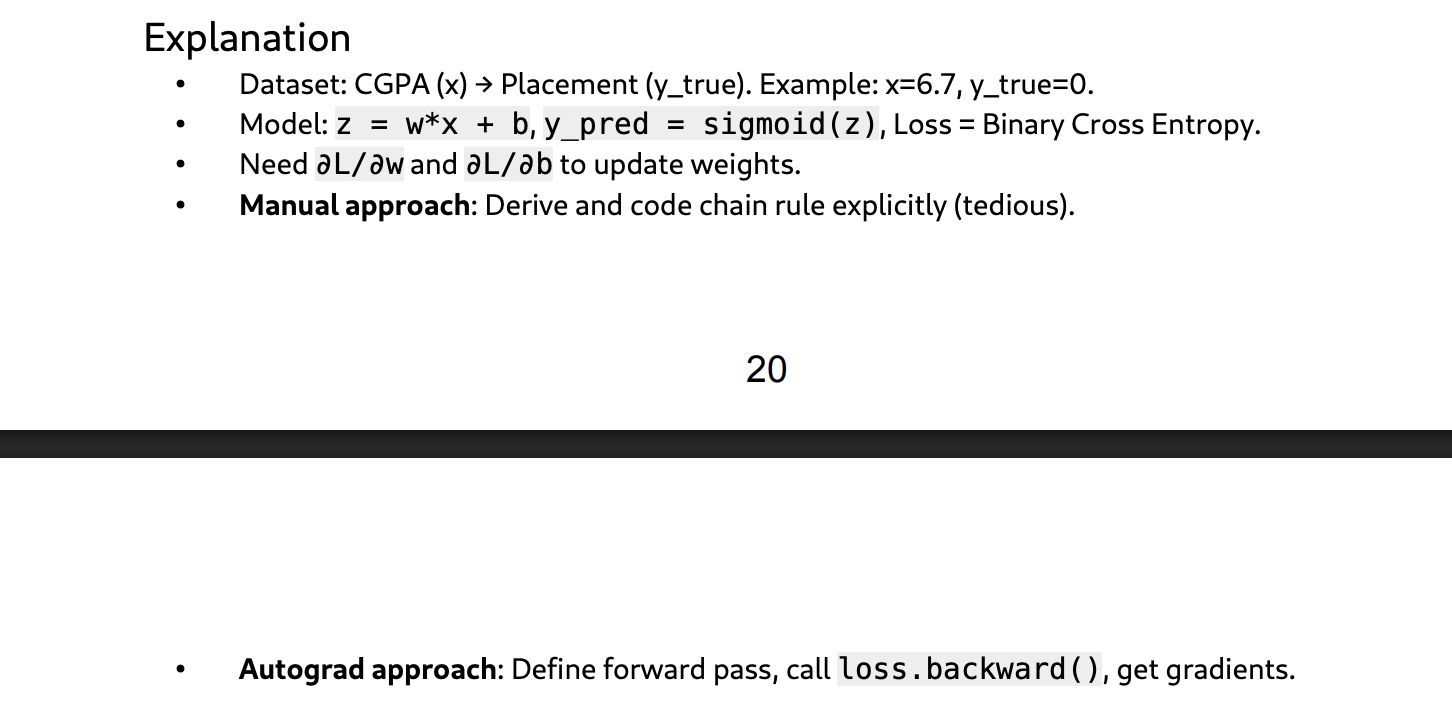

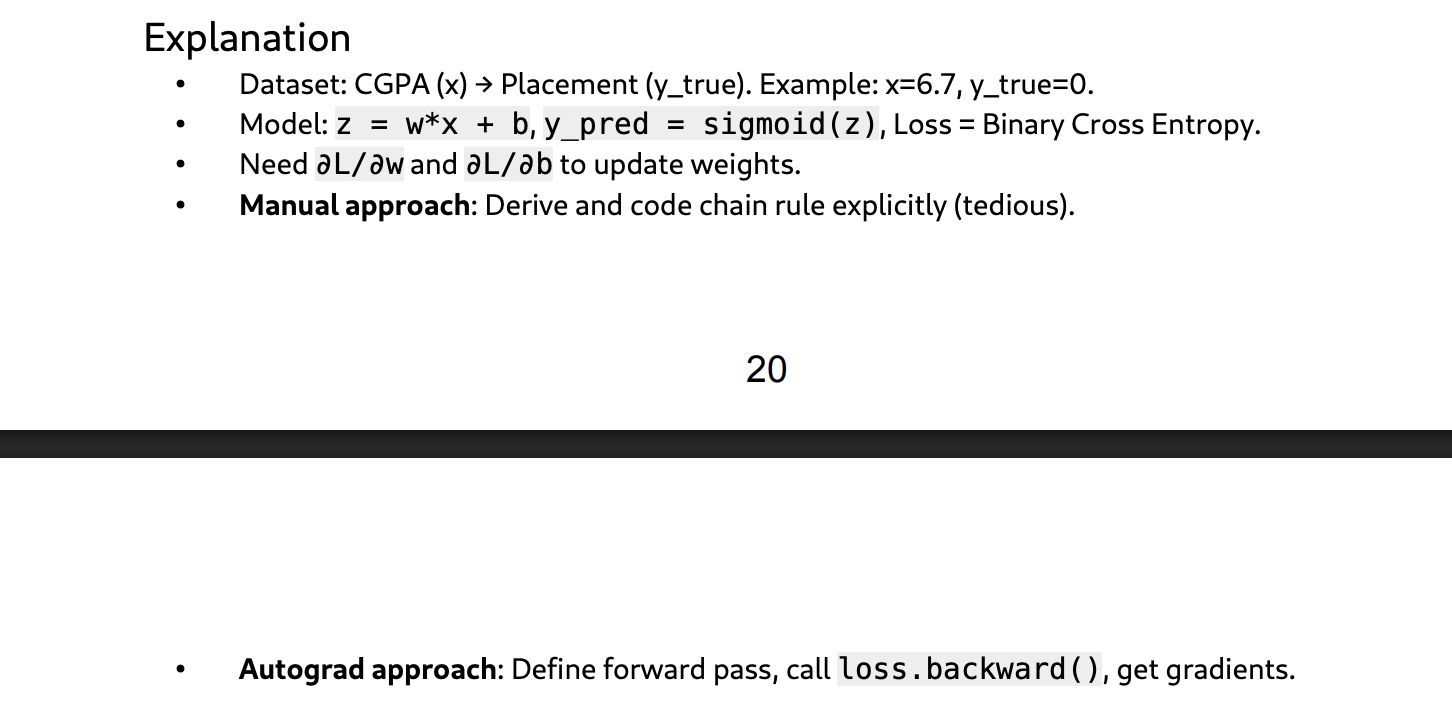

#### Manual Code (for comparison)

In [6]:
# Manual derivatives (conceptual)
import torch
#Inputs
x=torch.tensor(6.7) #Input feature
y_true=torch.tensor(0.0) #True label(binary)

w=torch.tensor(1.0) #weight
b=torch.tensor(0.0) #bias
# Forward
z = w * x + b
y_pred =torch.sigmoid(z) # sigmoid
loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 -
y_pred))
# Manual gradients (chain rule)
dL_dy_pred = (y_pred - y_true) / (y_pred * (1 - y_pred))
dy_pred_dz = y_pred * (1 - y_pred)
dz_dw = x
dz_db = 1
dL_dw = dL_dy_pred * dy_pred_dz * dz_dw # = (y_pred - y_true) * x
dL_db = dL_dy_pred * dy_pred_dz * dz_db # = (y_pred - y_true)

# Gradients
print(f"∂L/∂w = {dL_dw}") # (y_pred - y_true) * x
print(f"∂L/∂b = {dL_db}") # (y_pred - y_true)

∂L/∂w = 6.691762447357178
∂L/∂b = 0.998770534992218


In [7]:
print(f"Manual Gradient of loss w.r.t weight (dw): {dL_dw}")
print(f"Manual Gradient of loss w.r.t bias (db): {dL_db}")

Manual Gradient of loss w.r.t weight (dw): 6.691762447357178
Manual Gradient of loss w.r.t bias (db): 0.998770534992218


#### Using AutoGrad

In [8]:
import torch
# Data
x = torch.tensor(6.7)
y_true = torch.tensor(0.0)
# Parameters with gradient tracking
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
# Forward pass
z = w * x + b
y_pred = torch.sigmoid(z)
loss = torch.nn.functional.binary_cross_entropy(y_pred, y_true) # or manual formula
# Backward pass (automatic gradients)
loss.backward()
# Gradients
print(f"∂L/∂w = {w.grad}") # (y_pred - y_true) * x
print(f"∂L/∂b = {b.grad}") # (y_pred - y_true)

∂L/∂w = 6.6917619705200195
∂L/∂b = 0.9987704753875732


## Working with Vector Inputs

Explanation
- When input is a vector, output is a multivariable function.
- Gradient w.r.t each input variable is computed separately.
- Example: y = mean(x²) where x = [x1, x2, x3].

In [10]:
import torch
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = (x ** 2).mean() # (1^2 + 2^2 + 3^2)/3 = (1+4+9)/3 = 14/3 ≈4.6667
y.backward()
print(x.grad) # dy/dx = [2*x1/3, 2*x2/3, 2*x3/3] = [0.6667,1.3333, 2.0]

tensor([0.6667, 1.3333, 2.0000])


### 7. Clearing Gradients
Explanation
- Calling .backward() multiple times accumulates gradients (adds new gradients to
existing .grad).
- Always zero out gradients before next backward pass to avoid incorrect values.
- Use x.grad.zero_() (in-place operation).

####  Code & Output (Problem)

In [11]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()
print(x.grad) # 6.0

# Second forward+backward without clearing
y = x ** 2
y.backward()
print(x.grad) # 6.0 + 6.0 = 12.0 (WRONG for second pass)

tensor(6.)
tensor(12.)


#### Solution

In [12]:
x = torch.tensor(3.0, requires_grad=True)
# First pass
y = x ** 2
y.backward()
print(x.grad) # 6.0

# Clear gradients(Crucial Step)
x.grad.zero_()

# Second pass
y = x ** 2
y.backward()
print(x.grad) # 6.0 (correct)

tensor(6.)
tensor(6.)


### 8. Disabling Gradient Tracking


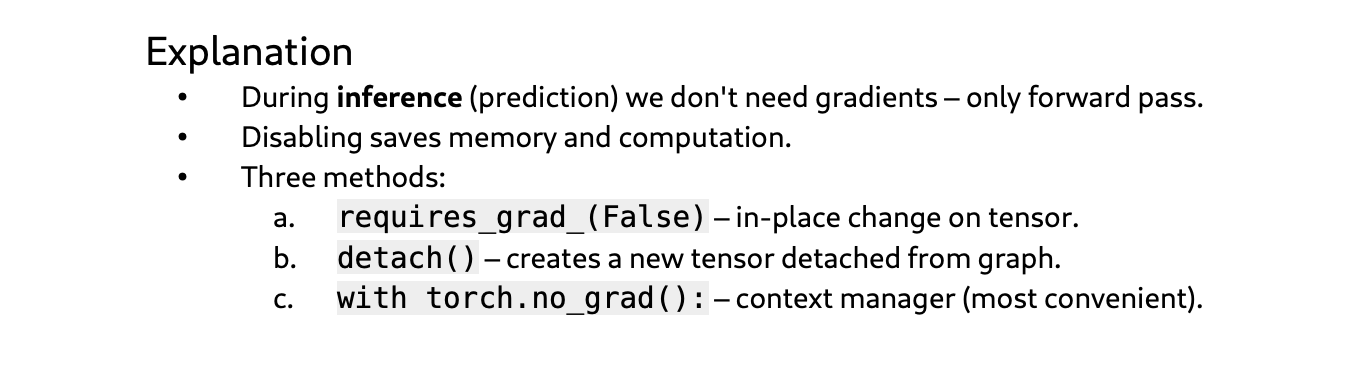

##### Method 1: requires_grad_(False)

In [15]:
x = torch.tensor(3.0, requires_grad=True)
x.requires_grad_(False)
print(x.requires_grad) # False
y = x ** 2
y.backward()# would raise error because no gradient tracking

False


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

##### Method 2: detach()

In [17]:
x = torch.tensor(3.0, requires_grad=True)
z = x.detach() # z has same data but no gradient tracking
print(z.requires_grad) # False
y = z ** 2
y.backward() # -> RuntimeError

False


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

### Method 3: with torch.no_grad(): (Recommended)

In [18]:
x = torch.tensor(3.0, requires_grad=True)
with torch.no_grad():
 y = x ** 2
print(y.requires_grad) # False
y.backward() #-> Error

False


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn